In [40]:
import numpy as np
from dipy.core.gradients import gradient_table
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti, save_nifti
from dipy.segment.mask import median_otsu
from dipy.reconst.dti import TensorModel

from matplotlib import pyplot as plt
import os

In [50]:
root = 'experiments/hardi150_denoise_260310_224426/results/' # **YOUR ROOT OF DENOISED DATA**
denoised_data = {}

hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames('stanford_hardi')
data, affine = load_nifti(hardi_fname)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)

# non b0 mask
sel_b = bvals != 0
b0_size = 10
eps = 1e-7

# create a new gradient table on non b0 directions
gtab = gradient_table(bvals[sel_b], bvecs[sel_b])
raw_gtab = gradient_table(bvals, bvecs)


def normalize_per_direction(vol):
    vol = vol.astype(np.float32)
    vmin = np.min(vol, axis=(0, 1, 2), keepdims=True)
    vmax = np.max(vol, axis=(0, 1, 2), keepdims=True)
    return (vol - vmin) / (vmax - vmin + eps)

# PLEASE DOUBLE CHECK THE PATH BELOW
# The denoised file can contain either:
#   (1) only non-b0 directions, or
#   (2) all directions including b0.
# denoised_data['n2s'], _ = load_nifti(root + 'n2s_denoised.nii.gz')
# denoised_data['n2n'], _ = load_nifti(root + 'n2n_denoised.nii.gz')
# denoised_data['dip'], _ = load_nifti(root + 'dip_denoised.nii.gz')
# denoised_data['p2s'], _ = load_nifti(root + 'p2s_denoised.nii.gz')
denoised_data['our'], _ = load_nifti(root + 'hardi150_denoised.nii.gz')

# normalize denoised data consistently with raw data
for k in list(denoised_data.keys()):
    v = denoised_data[k]
    if v.shape[-1] == data.shape[-1]:
        denoised_data[k] = normalize_per_direction(v)
    elif v.shape[-1] == int(np.sum(sel_b)):
        v_non_b0 = normalize_per_direction(v)
        raw_b0 = normalize_per_direction(data[:, :, :, :b0_size])
        denoised_data[k] = np.concatenate((raw_b0, v_non_b0), axis=-1)
    else:
        raise ValueError(f"Unexpected number of directions in {k}: {v.shape[-1]}")

print('Data loading done!')


Data loading done!


In [51]:
print('Computing brain mask...')
b0_mask, mask = median_otsu(data, vol_idx=[0])

print('Computing tensors...')
tenmodel = TensorModel(raw_gtab)
tensorfit = tenmodel.fit(data, mask=mask)

Computing brain mask...
Computing tensors...


Computing worst-case/best-case SNR using the corpus callosum...
(81, 106, 76)


C:\Users\shrey\AppData\Local\Temp\ipykernel_10236\873809487.py:41: DeprecationWarning: Please use `binary_dilation` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  from scipy.ndimage.morphology import binary_dilation


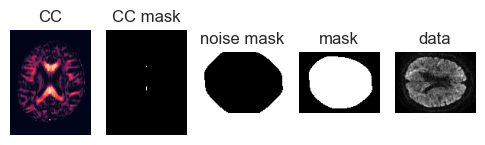

In [52]:
print('Computing worst-case/best-case SNR using the corpus callosum...')
from dipy.segment.mask import segment_from_cfa
from dipy.segment.mask import bounding_box

threshold = (0.6, 1, 0, 0.1, 0, 0.1)

CC_box = np.zeros_like(data[..., 0])

mins, maxs = bounding_box(mask)
mins = np.array(mins)
maxs = np.array(maxs)
diff = (maxs - mins) // 4
bounds_min = mins + diff
bounds_max = maxs - diff

CC_box[bounds_min[0]:bounds_max[0],
       bounds_min[1]:bounds_max[1],
       bounds_min[2]:bounds_max[2]] = 1

mask_cc_part, cfa = segment_from_cfa(tensorfit, CC_box, threshold,
                                     return_cfa=True)


import matplotlib.pyplot as plt

region = 40

# visualize the masks and ROI
fig = plt.figure('Corpus callosum segmentation')
plt.subplot(1, 5, 1)
plt.title("CC")
plt.axis('off')
red = cfa[..., 0]
plt.imshow(np.rot90(red[...,region]))

plt.subplot(1, 5, 2)
plt.title("CC mask")
plt.axis('off')
plt.imshow(np.rot90(mask_cc_part[...,region]), cmap='gray')

from scipy.ndimage.morphology import binary_dilation
mask_noise = binary_dilation(mask, iterations=10)

mask_noise = ~mask_noise
print(mask_noise.shape)

plt.subplot(1, 5, 3)
plt.title("noise mask")
plt.axis('off')
plt.imshow(mask_noise[:,:,40], cmap='gray')

plt.subplot(1, 5, 4)
plt.title("mask")
plt.axis('off')
plt.imshow(mask[:,:,40], cmap='gray')


plt.subplot(1, 5, 5)
plt.title("data")
plt.axis('off')
plt.imshow(data[:,:,40,40], cmap='gray')

In [53]:
# normalize raw data for metric computation
data_normalized = normalize_per_direction(data)


In [54]:
mean_signal = np.mean(data_normalized[mask_cc_part], axis=0)
noise_std = np.std(data_normalized[mask_noise, :], axis=0) + eps
mean_bg = np.mean(data_normalized[mask_noise, :], axis=0)

mean_signal_denoised = {}
denoised_noise_std = {}
denoised_mean_bg = {}

# normalize denoised data for metric calculation
for k, v in denoised_data.items():
    mean_signal_denoised[k] = np.mean(v[mask_cc_part], axis=0)
    denoised_noise_std[k] = np.std(v[mask_noise, :], axis=0) + eps
    denoised_mean_bg[k] = np.mean(v[mask_noise, :], axis=0)

In [60]:
# metric calculation starts here

SNRs = {}
CNRs = {}

SNR = mean_signal / noise_std
CNR = np.abs(mean_signal - mean_bg) / noise_std

SNR = SNR[sel_b]
CNR = CNR[sel_b]

SNRs['raw'] = SNR
CNRs['raw'] = CNR

print('raw', '[SNR] mean: %.4f std: %.4f' % (np.mean(SNR), np.std(SNR)))
print('raw', '[CNR] mean: %.4f std: %.4f' % (np.mean(CNR), np.std(CNR)))

for k in denoised_data.keys():
    SNR = mean_signal_denoised[k] / denoised_noise_std[k]
    CNR = np.abs(mean_signal_denoised[k] - denoised_mean_bg[k]) / denoised_noise_std[k]

    SNR = SNR[sel_b]
    CNR = CNR[sel_b]
    SNR -= SNRs['raw']
    CNR -= CNRs['raw']
    SNRs[k] = SNR
    CNRs[k] = CNR
    print("=================")
    print(k, '[SNR delta] mean: %.4f std: %.4f best: %.4f worst: %.4f' % (np.mean(SNR), np.std(SNR), np.max(SNR), np.min(SNR)))
    print(k, '[CNR delta] mean: %.4f std: %.4f best: %.4f worst: %.4f' % (np.mean(CNR), np.std(CNR), np.max(CNR), np.min(CNR)))

raw [SNR] mean: 5.1141 std: 2.4988
raw [CNR] mean: 4.6567 std: 2.4976
our [SNR delta] mean: 1.7754 std: 2.6717 best: 5.6468 worst: -2.5784
our [CNR delta] mean: -4.8398 std: 2.6316 best: -1.0098 worst: -9.0737


C:\Users\shrey\AppData\Local\Temp\ipykernel_10236\187862253.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="variable", y="value", data=pd.melt(df_diff), fliersize=0, palette=my_pal)


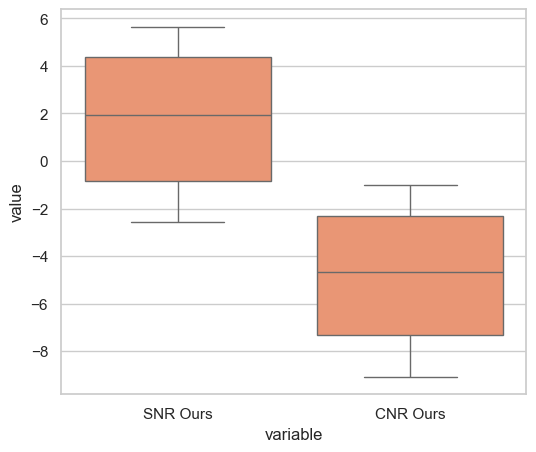

In [61]:
%matplotlib inline
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Only create columns for the 'our' data we actually loaded
df_diff = pd.DataFrame({
    'SNR Ours': SNRs['our'],
    'CNR Ours': CNRs['our']
})

# 2. Setup the plot style (made the figure slightly narrower for just one method)
sns.set(rc={'figure.figsize':(6,5)})
sns.set(style="whitegrid")
set2 = sns.color_palette('Set2')

# 3. Update the color palette mapping to match our new DataFrame columns
my_pal = {
    "SNR Ours": set2[1],
    "CNR Ours": set2[1]
}

# 4. Generate and show the plot
ax = sns.boxplot(x="variable", y="value", data=pd.melt(df_diff), fliersize=0, palette=my_pal)

# plt.savefig('quantitative.svg', dpi=500, bbox_inches='tight')
plt.show()